In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
%matplotlib widget

import matplotlib.pyplot as plt


import moabb
import numpy as np
import seaborn as sns
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2023-10-11 12:06:57.338452: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Tensorflow not install, you could not use those pipelines
To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import BNCI2014_008, BNCI2014_009, EPFLP300
plt.style.use('default')

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_008()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[4],
                                         return_epochs=True)

Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/data/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/paradigms/base.py:346: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
meta

,subject,session,run
0,4,session_0,run_0
1,4,session_0,run_0
2,4,session_0,run_0
3,4,session_0,run_0
4,4,session_0,run_0
...,...,...,...
4195,4,session_0,run_0
4196,4,session_0,run_0
4197,4,session_0,run_0
4198,4,session_0,run_0


In [5]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from mne.decoding import Scaler


X = epochs.get_data()
y = labels

X.shape


(4200, 8, 26)

In [6]:
tl.set_backend('cupy')
X = tl.tensor(X)

In [7]:
from hoda.hoda import HODA, mode_scatter, center, mode_scatter
from hoda.tenalg import trunc_eigh, lanczos, pinvh, ledoit_wolf_shrinkage
import warnings
warnings.filterwarnings("ignore")

hoda = HODA(
            rank=None,
            max_iter=64,
            tol=0,
            init ='svd',
            shrinkage=('lw','lw'),
            toeplitz=None,
            obj='tr',
            solver='lanczos',
            taper=False,
            keep_train_info=True,
            verbose=True,
            lasso=False,
            prune=True,
            combine_p='fisher'
    
        )
hoda.fit(X,y)

Initializing factors...
Fitting discriminative tucker model...


  0%|          | 0/64 [00:00<?, ?it/s]

Fitted tucker model of rank [1, 2] ...


HODA(init='svd', keep_train_info=True, max_iter=64, shrinkage=('lw', 'lw'),
     tol=0, verbose=True)

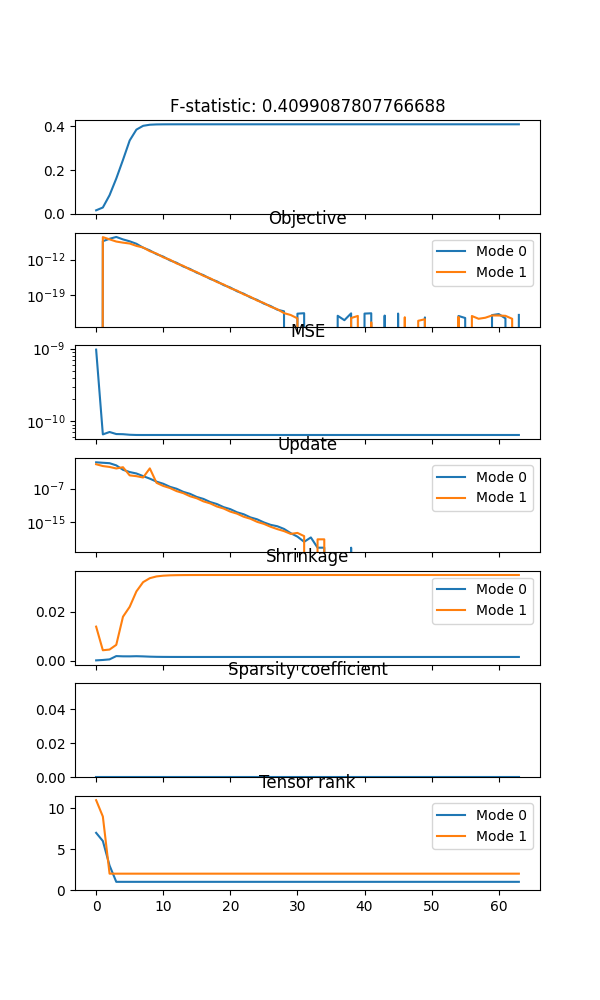

In [8]:
if hoda.keep_train_info:
    fig, axs = plt.subplots(7,1, sharex=True, figsize=(6,10))

    axs[0].set_title(f"F-statistic: {hoda.train_info_['f_stat'][-1]}")
    axs[0].plot(hoda.train_info_["f_stat"])
    axs[0].set_ylim([0,None])

    axs[1].set_title('Objective')
    axs[1].semilogy(np.asarray(hoda.train_info_["mode_objective"]).T, label=['Mode 0', 'Mode 1'])
    axs[1].legend()

    axs[2].set_title('MSE')
    axs[2].semilogy(hoda.train_info_["mse"])

    axs[3].set_title('Update')
    axs[3].semilogy(tl.to_numpy(tl.tensor(hoda.train_info_["mode_update"])).T, label=['Mode 0', 'Mode 1'])
    axs[3].legend()

    axs[4].set_title('Shrinkage')
    axs[4].plot(tl.to_numpy(tl.tensor(hoda.train_info_["mode_shrinkage"])).T, label=['Mode 0', 'Mode 1'])
    axs[4].legend()
    
    axs[5].set_title('Sparsity coefficient')
    axs[5].plot(tl.to_numpy(tl.tensor([l for l in hoda.train_info_['lambd']])))
    axs[5].set_ylim([0,None])


    axs[6].set_title('Tensor rank')
    axs[6].plot(tl.to_numpy(tl.tensor(hoda.train_info_["mode_rank"])).T, label=['Mode 0', 'Mode 1'])
    axs[6].set_ylim([0,None])
    axs[6].legend()
    

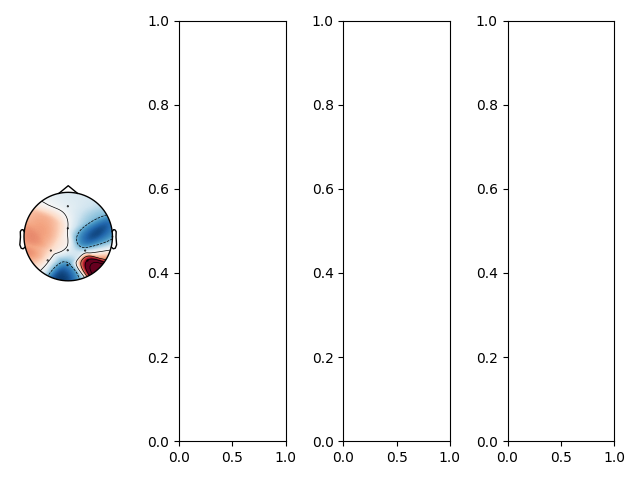

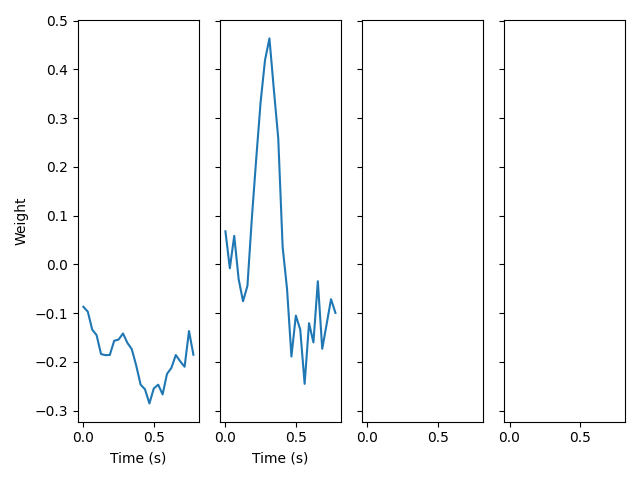

In [9]:
col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    w = tl.to_numpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


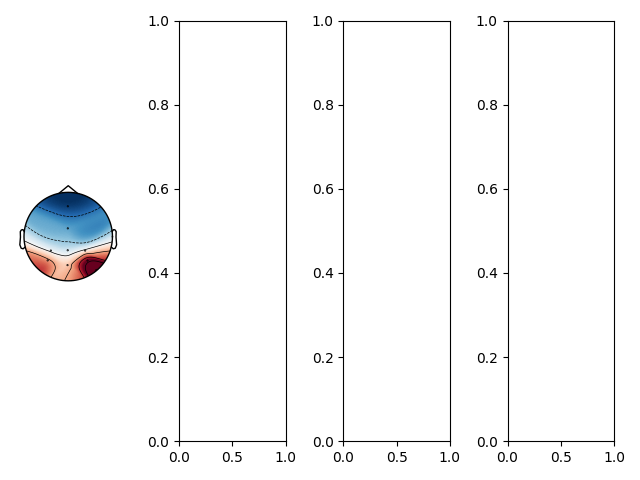

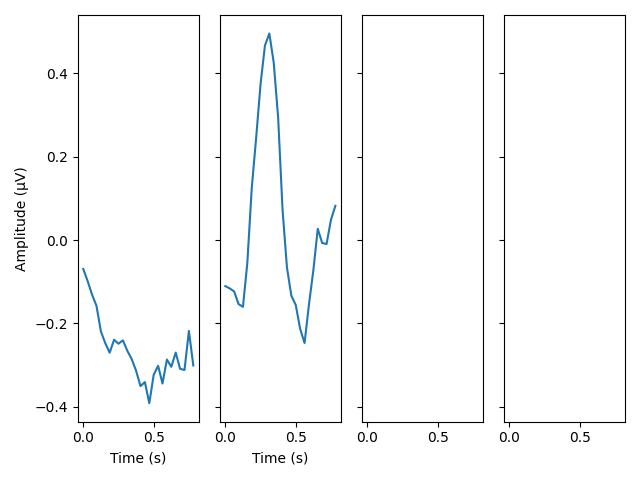

In [10]:
n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_[1]):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude (µV)');

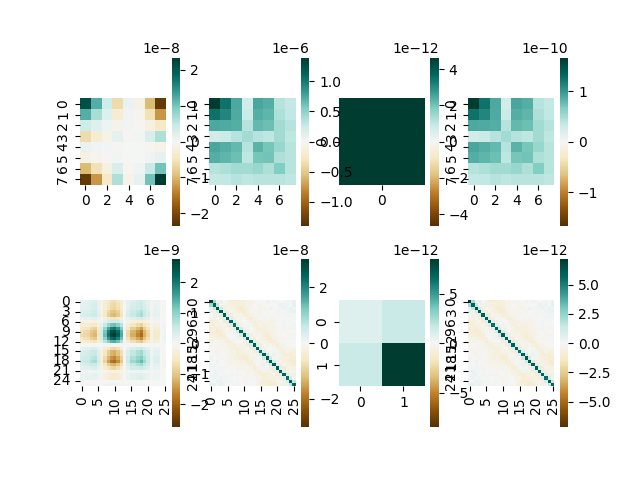

In [11]:
_, axs = plt.subplots(2,4,)
for k in range(2):
    
    scatter_b = tl.to_numpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = tl.to_numpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= tl.to_numpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov_w=  tl.to_numpy(hoda.cov_w_[k])
    vmax = np.max(np.abs(cov_w))
    sns.heatmap(cov_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

In [12]:
Xt = hoda.transform(X)

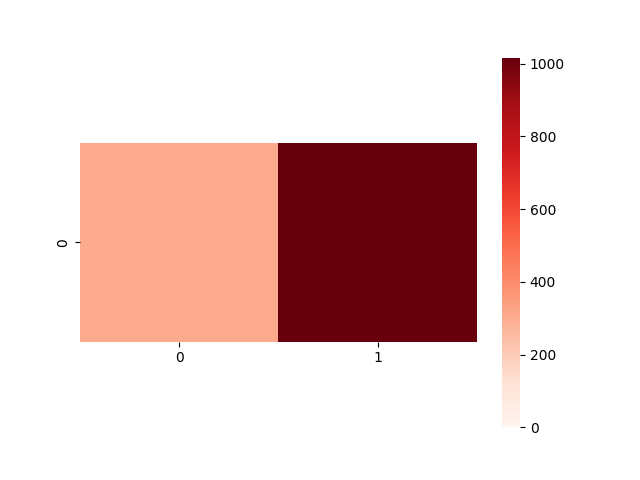

In [13]:
import scipy.stats
import seaborn as sns
from sklearn.feature_selection import f_classif

n_samples, *shape_t = Xt.shape
Xt_flat = Xt.reshape((n_samples, -1))
F, p = f_classif(tl.to_numpy(Xt_flat), y)
F = F.reshape(shape_t)
p = p.reshape(shape_t)


fig, ax = plt.subplots(1,1)
sns.heatmap(F, vmin=0, mask=p>0.5, ax=ax, cmap='Reds')
ax.set_aspect(1)


In [14]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA


order = np.argsort(-F.flatten())
Xt_viz = tl.to_numpy(Xt.reshape((Xt.shape[0],-1)))
n_components = min(3, math.prod(Xt.shape[1:]))
decomp  = PCA(n_components=n_components, whiten=True)
Xt_viz = decomp.fit_transform(Xt_viz)


IndexError: index 2 is out of bounds for axis 1 with size 2

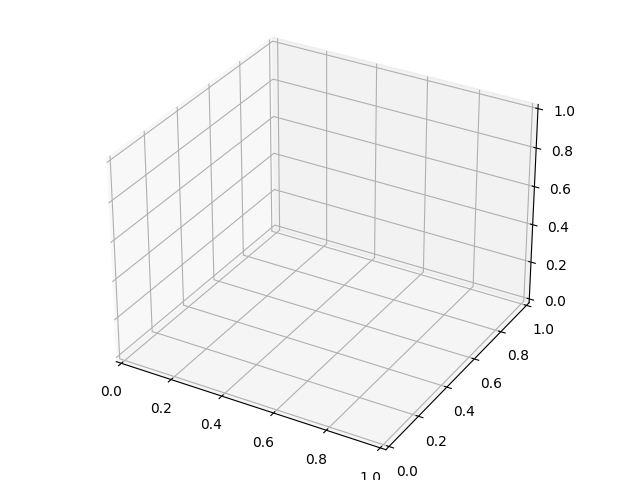

In [15]:
import re, seaborn as sns
import numpy as np

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

# axes instance
fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)

cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
c = np.vectorize(cmap.get)(y)
sc = ax.scatter(Xt_viz[:,0],Xt_viz[:,1],Xt_viz[:,2], c=c)
ax.set_aspect('equal')


In [ ]:
target_avg = tl.to_numpy(Xt[y=='Target'].mean(axis=0))
nontarget_avg = tl.to_numpy(Xt[y=='NonTarget'].mean(axis=0))
fig, axs= plt.subplots(1,2)
vmax = max(np.max(np.abs(target_avg)), np.max(np.abs(nontarget_avg)))
sns.heatmap(target_avg, ax=axs[0], center=0, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
sns.heatmap(nontarget_avg, ax=axs[1], center=0, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
for ax in axs:
    ax.set_aspect(1)

In [ ]:
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
vmax = np.max(np.abs(target.data))
vmax = max(vmax, np.max(np.abs(non_target.data)))
vmax *=1.1e6

joint_args=dict(
    ts_args=dict(
        ylim=dict(eeg=[-vmax,vmax]),
        unit=True,
    )
)


contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(**joint_args)

epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))

target = epochs_rec['Target'].average()
non_target = epochs_rec['NonTarget'].average()
contrast_rec = combine_evoked([target, non_target], weights=[1,-1])
_= contrast_rec.plot_joint(**joint_args)

epochs_defl = epochs.copy()
epochs_defl._data -= epochs_rec.get_data()

target = epochs_defl['Target'].average()
non_target = epochs_defl['NonTarget'].average()
contrast_defl = combine_evoked([target, non_target], weights=[1,-1])
_= contrast_defl.plot_joint(**joint_args)

In [ ]:
#contrast_rec.animate_topomap(times = contrast_defl.times, frame_rate=contrast.info['sfreq'], blit=False, butterfly=True)

In [ ]:
#contrast_defl.animate_topomap(times = contrast_defl.times, frame_rate=contrast.info['sfreq'], blit=False, butterfly=True)

## Classification

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
import pandas as pd

Xt = hoda.transform(X)
Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0],-1)))
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr') 
lda.fit(Xt_flat, y)
score_pred = lda.decision_function(Xt_flat)
df = pd.DataFrame(dict(score=score_pred,y=y))
sns.displot(df, x='score', hue='y')
plt.axvline(0, color='red')
print(roc_auc_score(y,score_pred))